<center>

# [Компьютерное зрение](http://rairi.ru/wiki/index.php/%D0%9A%D0%BE%D0%BC%D0%BF%D1%8C%D1%8E%D1%82%D0%B5%D1%80%D0%BD%D0%BE%D0%B5_%D0%B7%D1%80%D0%B5%D0%BD%D0%B8%D0%B5)

## <center> Семинар 11 - Трекинг

<a target="_blank" href="https://colab.research.google.com/github/alexmelekhin/cv_course_2023/blob/main/seminars/seminar_11/Seminar_11.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

***

In [2]:
# !pip install torch==1.13.1+cu116 torchvision==0.14.1+cu116 --extra-index-url https://download.pytorch.org/whl/cu116
!pip install ultralytics filterpy lap
!pip uninstall -y numpy protobuf
!pip install -U numpy==1.23.5 protobuf==3.20.3

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu116
ERROR: Could not find a version that satisfies the requirement torch==1.13.1+cu116 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0, 2.11.0)
ERROR: No matching distribution found for torch==1.13.1+cu116
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 66.3 MB/s eta 0:00:00
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=96584ab6abb50426e5a5fa91cbbb3770df2417dc766f2981055ba6ad1cf3cdfa
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
 

In [1]:
from typing import Tuple
from time import time
import types
from pathlib import Path

from scipy.optimize import linear_sum_assignment
import numpy as np
import cv2
import matplotlib.pyplot as plt

from ultralytics import YOLO

# Вспомогательные функции

In [2]:
def show_image(img: np.ndarray) -> None:
    plt.figure(figsize=(10,5))
    plt.imshow(img)
    plt.xticks([])
    plt.yticks([])
    plt.show()


def detection_visualization(
    img_path: Path, preds: np.ndarray
) -> np.ndarray:
    img = cv2.imread(str(img_path)) # Read image with cv2
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB
    for i in range(len(preds)):
        cv2.rectangle(
            img,
            (int(preds[i][0]), int(preds[i][1])),
            (int(preds[i][2]), int(preds[i][3])),
            color=(0, 255, 0),
            thickness=3,
        )
    return img


def tracking_visualization(
    img_path: Path, preds: np.ndarray
) -> np.ndarray:
    img = cv2.imread(str(img_path)) # Read image with cv2
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB
    for i in range(len(preds)):
        cv2.rectangle(
            img,
            (int(preds[i][0]), int(preds[i][1])),
            (int(preds[i][2]), int(preds[i][3])),
            color=(0, 255, 0),
            thickness=3,
        )
        cv2.putText(
            img,
            str(int(preds[i][4])),
            (int(preds[i][0]), int(preds[i][1])),
            cv2.FONT_HERSHEY_SIMPLEX,
            fontScale=2,
            color=(0, 255, 0),
            thickness=3
        )
    return img


# Датасет

В рамках данного семинара мы будем использовать трек `MOT17-09` из датасета MOT Challenge https://motchallenge.net/

Ссылка на скачивание датасета https://motchallenge.net/data/MOT17Det/

In [3]:
!ls ../content

ByteTrack  drive  sample_data  yolov8s.pt


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
dataset_dir = Path("/content/drive/MyDrive/Colab Notebooks/MOT17/train/MOT17-09-DPM/img1")  # путь к директории с изображениями трека MOT17-09
frames_list = sorted([f for f in dataset_dir.iterdir()])

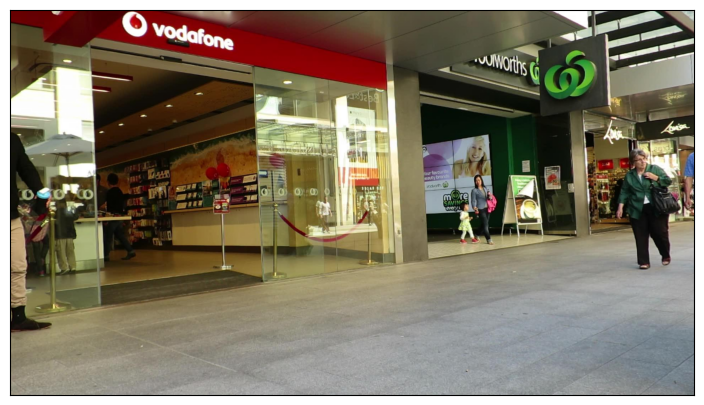

In [6]:
img = cv2.cvtColor(cv2.imread(str(frames_list[0])), cv2.COLOR_BGR2RGB)
show_image(img)

# Детекция с помощью YOLOv8

В качестве бэкбона детекции мы будем использовать YOLOv8s из библиотеки ultralytics: https://github.com/ultralytics/ultralytics

In [7]:
class YoloDetector:
    def __init__(self, conf_threshold: float = 0.5) -> None:
        self.backbone = YOLO("yolov8s.pt")
        self.conf_threshold = conf_threshold

    def __call__(self, img_path: Path) -> np.ndarray:
        preds = self.backbone.predict(source=img_path, conf=self.conf_threshold, show=False, classes=0)
        preds = preds[0].boxes.data.cpu().numpy()[:, :5]
        return preds


image 1/1 /content/drive/MyDrive/Colab Notebooks/MOT17/train/MOT17-09-DPM/img1/000001.jpg: 384x640 7 persons, 48.9ms
Speed: 2.4ms preprocess, 48.9ms inference, 38.9ms postprocess per image at shape (1, 3, 384, 640)


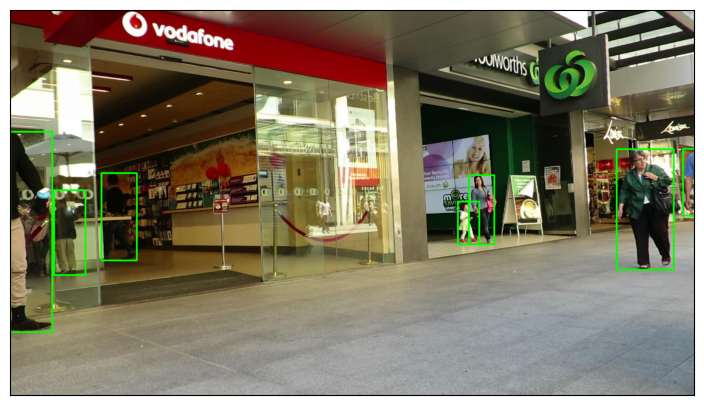

In [8]:
detector = YoloDetector()
preds = detector(frames_list[0])

out_frame = detection_visualization(frames_list[0], preds)
show_image(out_frame)

# Алгоритм трекинга SORT

SORT: https://arxiv.org/abs/1602.00763

Разделы "3.3. Data Association" и "3.4. Creation and Deletion of Track Identities" описывают алгоритм соотнесения результатов детекции последовательных кадров:

> **3.3. Data Association**
>
> In assigning detections to existing targets, each target’s
> bounding box geometry is estimated by predicting its new
> location in the current frame. The assignment cost matrix is
> then computed as the intersection-over-union (IOU) distance
> between each detection and all predicted bounding boxes
> from the existing targets. The assignment is solved optimally
> using the Hungarian algorithm. Additionally, a minimum
> IOU is imposed to reject assignments where the detection to
> target overlap is less than $IOU_{min}$.
>
> We found that the IOU distance of the bounding boxes
> implicitly handles short term occlusion caused by passing targets.
> Specifically, when a target is covered by an occluding
> object, only the occluder is detected, since the IOU distance
> appropriately favours detections with similar scale. This allows
> both the occluder target to be corrected with the detection while
> the covered target is unaffected as no assignment is made.

> **3.4. Creation and Deletion of Track Identities**
>
> When objects enter and leave the image, unique identities
> need to be created or destroyed accordingly. For creating
> trackers, we consider any detection with an overlap less than
> $IOU_{min}$ to signify the existence of an untracked object. The
> tracker is initialised using the geometry of the bounding box
> with the velocity set to zero. Since the velocity is unobserved
> at this point the covariance of the velocity component is initialised
> with large values, reflecting this uncertainty. Additionally, the new
> tracker then undergoes a probationary period where the target needs
> to be associated with detections to accumulate enough evidence in order
> to prevent tracking of false positives.
>
> Tracks are terminated if they are not detected for $T_{Lost}$
> frames. This prevents an unbounded growth in the number
> of trackers and localisation errors caused by predictions over
> long durations without corrections from the detector. In all
> experiments $T_{Lost}$ is set to 1 for two reasons. Firstly, the constant
> velocity model is a poor predictor of the true dynamics
> and secondly we are primarily concerned with frame-to-frame
> tracking where object re-identification is beyond the scope of
> this work. Additionally, early deletion of lost targets aids efficiency.
> Should an object reappear, tracking will implicitly resume under a new identity.

# Венгерский алгоритм (Hungarian algorithm)

- [Wikipedia](https://en.wikipedia.org/wiki/Hungarian_algorithm)
- Реализация в библиотеке scipy: [`scipy.optimize.linear_sum_assignment`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html)
- Реализация в библиотеке [lap](https://github.com/gatagat/lap): `lap.lapjv`

## Задание 1:

Реализуйте Венгерский алгоритм. Сравните возвращаемые значения с библиотечной функцией [`scipy.optimize.linear_sum_assignment`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linear_sum_assignment.html).

In [9]:
def hungarian_algorithm(cost_matrix: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Solves the assignment problem using the Hungarian algorithm.

    Args:
        cost_matrix (np.ndarray): Numpy array of shape (n, m) representing the cost matrix.

    Returns:
        A tuple of two numpy arrays (row_ind, col_ind) representing the row and column indices
        of the assigned cells in the cost matrix.
    """
    n, m = cost_matrix.shape
    size = max(n, m)

    # Pad to square matrix if needed
    big = cost_matrix.max() * size + 1
    C = np.full((size, size), fill_value=big, dtype=float)
    C[:n, :m] = cost_matrix.astype(float)

    # Step 1: subtract row minima
    C -= C.min(axis=1, keepdims=True)
    # Step 2: subtract column minima
    C -= C.min(axis=0, keepdims=True)

    starred = np.zeros((size, size), dtype=bool)
    primed  = np.zeros((size, size), dtype=bool)
    row_cover = np.zeros(size, dtype=bool)
    col_cover = np.zeros(size, dtype=bool)

    # Find an initial set of independent starred zeros
    for i in range(size):
        for j in range(size):
            if C[i, j] == 0 and not row_cover[i] and not col_cover[j]:
                starred[i, j] = True
                row_cover[i] = True
                col_cover[j] = True
    row_cover[:] = False
    col_cover[:] = False

    # Cover each column that has a starred zero
    col_cover = starred.any(axis=0).copy()

    while not col_cover.all():
        # Find an uncovered zero
        r, c = -1, -1
        for i in range(size):
            if row_cover[i]:
                continue
            for j in range(size):
                if C[i, j] == 0 and not col_cover[j]:
                    r, c = i, j
                    break
            if r >= 0:
                break

        if r < 0:
            # No uncovered zero: subtract minimum uncovered value from uncovered rows,
            # add it to covered columns
            h = C[np.ix_(~row_cover, ~col_cover)].min()
            C[~row_cover] -= h
            C[:, col_cover] += h
            continue

        primed[r, c] = True

        # If there is a starred zero in the same row, cover the row and uncover the star's column
        star_cols = np.where(starred[r])[0]
        if len(star_cols) > 0:
            row_cover[r] = True
            col_cover[star_cols[0]] = False
        else:
            # Construct augmenting path starting at (r, c)
            path = [(r, c)]
            while True:
                last_c = path[-1][1]
                star_rows = np.where(starred[:, last_c])[0]
                if len(star_rows) == 0:
                    break
                sr = star_rows[0]
                path.append((sr, last_c))
                prime_cols = np.where(primed[sr])[0]
                path.append((sr, prime_cols[0]))

            # Augment: flip starred/unstarred along the path
            for pr, pc in path:
                starred[pr, pc] = not starred[pr, pc]

            primed[:] = False
            row_cover[:] = False
            col_cover = starred.any(axis=0).copy()

    # Extract assignment indices (only within the original matrix bounds)
    r_ind, c_ind = np.where(starred[:n, :m])
    order = np.argsort(r_ind)
    return r_ind[order], c_ind[order]


In [10]:
cost_matrix = np.array([[1, 2, 3],
                        [4, 5, 6],
                        [7, 8, 9]])
my_row_ind, my_col_ind = hungarian_algorithm(cost_matrix)
my_cost = cost_matrix[my_row_ind, my_col_ind].sum()
row_ind, col_ind = linear_sum_assignment(cost_matrix)
cost = cost_matrix[row_ind, col_ind].sum()

assert my_cost == cost

# Алгоритм трекинга ByteTrack

- Статья https://arxiv.org/abs/2110.06864
- Код https://github.com/ifzhang/ByteTrack


## Вопрос 1:

В чем заключается ключевая особенность метода BYTE?

**Ответ:**

Ключевая особенность метода BYTE состоит в **двухэтапном сопоставлении детекций**, при котором в трекинг вовлекаются не только высококонфидентные, но и низококонфидентные детекции.

На первом этапе высококонфидентные детекции (выше порога `track_thresh`) сопоставляются с активными треками с помощью матрицы стоимостей на основе IoU и венгерского алгоритма — стандартно, как в SORT. На втором этапе оставшиеся неприписанные треки сопоставляются с низококонфидентными детекциями (между `det_low_thresh` и `track_thresh`), которые большинство других трекеров просто отбрасывает. Это позволяет не терять треки в моменты частичного перекрытия объектов или временного падения качества детекции, поскольку низкоконфидентная детекция всё равно несёт информацию о местоположении объекта.

Таким образом, BYTE добивается высокой полноты трекинга (MOTA/HOTA) без дополнительных Re-ID признаков, используя «дешёвые» детекции, которые ранее игнорировались.


In [19]:
!git clone https://github.com/ifzhang/ByteTrack.git
%cd ByteTrack
!pip install -r requirements.txt
!python setup.py develop
%cd ..
!pip install cython
!pip install 'git+https://github.com/cocodataset/cocoapi.git#subdirectory=PythonAPI'
!pip install cython_bbox

Cloning into 'ByteTrack'...
remote: Enumerating objects: 2007, done.
remote: Counting objects: 100% (346/346), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 2007 (delta 304), reused 296 (delta 296), pack-reused 1661 (from 1)
Receiving objects: 100% (2007/2007), 79.59 MiB | 44.78 MiB/s, done.
Resolving deltas: 100% (1160/1160), done.
/content/ByteTrack
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 48.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement onnxruntime==1.8.0 (from versions: 1.17.0, 1.

In [14]:
import numpy as np

# Небольшой workaround для старого ByteTrack и нового numpy
if not hasattr(np, "float"):
    np.float = float
if not hasattr(np, "int"):
    np.int = int
if not hasattr(np, "bool"):
    np.bool = bool

from yolox.tracker.byte_tracker import BYTETracker

fps = 30
frame_size = (1080, 1920)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
output_file = 'output.mp4'
video_writer = cv2.VideoWriter(output_file, fourcc, fps, frame_size[::-1])

args = types.SimpleNamespace(**{
    "track_thresh": 0.5,
    "track_buffer": 30,
    "match_thresh": 0.8,
    "mot20": False,

})
tracker = BYTETracker(args, frame_rate=fps)

det_times = []
track_times = []

for frame_path in frames_list:
    s_time = time()
    detections = detector(frame_path)
    det_times.append((time() - s_time) * 1000)  # in ms
    s_time = time()
    tracks = tracker.update(detections, frame_size, frame_size)
    track_times.append((time() - s_time) * 1000)  # in ms
    tracks = [t.tlbr.tolist() + [t.track_id] for t in tracks]
    out_frame = tracking_visualization(frame_path, tracks)
    video_writer.write(cv2.cvtColor(out_frame, cv2.COLOR_RGB2BGR))
    # cv2.imwrite(f"./output/{str(frame_path.name)}", cv2.cvtColor(out_frame, cv2.COLOR_RGB2BGR))
video_writer.release()

print(f"mean detection time: {np.mean(det_times)}, mean track time: {np.mean(track_times)}")


image 1/1 /content/drive/MyDrive/Colab Notebooks/MOT17/train/MOT17-09-DPM/img1/000001.jpg: 384x640 7 persons, 26.4ms
Speed: 12.4ms preprocess, 26.4ms inference, 4.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/drive/MyDrive/Colab Notebooks/MOT17/train/MOT17-09-DPM/img1/000002.jpg: 384x640 7 persons, 34.1ms
Speed: 6.1ms preprocess, 34.1ms inference, 5.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/drive/MyDrive/Colab Notebooks/MOT17/train/MOT17-09-DPM/img1/000003.jpg: 384x640 7 persons, 32.2ms
Speed: 11.9ms preprocess, 32.2ms inference, 5.9ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/drive/MyDrive/Colab Notebooks/MOT17/train/MOT17-09-DPM/img1/000004.jpg: 384x640 7 persons, 10.8ms
Speed: 17.1ms preprocess, 10.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /content/drive/MyDrive/Colab Notebooks/MOT17/train/MOT17-09-DPM/img1/000005.jpg: 384x640 7 persons, 10.8ms
Speed: 2.1ms prepro

## Задание 2

Объедините BYTE и любой трекер с Re-ID признаками (например, FairMOT). Можно воспользоваться инструкциями из репозитория: https://github.com/ifzhang/ByteTrack/tree/main/tutorials

Ответом на это задание должен быть код, записывающий видео работы метода для трека MOT17-09 в файл `reid_out.mp4`. Убедитесь, что код работает "end-to-end".

In [15]:
# Задание 2: BYTE + Re-ID с помощью BoT-SORT (ultralytics)
#
# BoT-SORT объединяет BYTE (двухэтапное сопоставление детекций) с
# Re-ID признаками внешнего вида (appearance features), что устраняет
# ошибки переключения идентификаторов при перекрытиях.
# В ultralytics BoT-SORT доступен через tracker="botsort.yaml".

fps = 30
frame_size = (1080, 1920)
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
output_file = 'reid_out.mp4'
video_writer = cv2.VideoWriter(output_file, fourcc, fps, frame_size[::-1])

reid_model = YOLO("yolov8s.pt")

det_times_reid = []
track_times_reid = []

for frame_path in frames_list:
    s_time = time()
    img = cv2.imread(str(frame_path))
    det_times_reid.append((time() - s_time) * 1000)

    s_time = time()
    results = reid_model.track(
        source=str(frame_path),
        persist=True,
        tracker="botsort.yaml",   # BYTE + Re-ID appearance features
        conf=0.5,
        classes=0,                # только класс "person"
        show=False,
        verbose=False,
    )
    track_times_reid.append((time() - s_time) * 1000)

    tracks = []
    if results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids   = results[0].boxes.id.cpu().numpy()
        for box, tid in zip(boxes, ids):
            tracks.append(list(box) + [tid])

    out_frame = tracking_visualization(frame_path, tracks)
    video_writer.write(cv2.cvtColor(out_frame, cv2.COLOR_RGB2BGR))

video_writer.release()
print(f"Видео сохранено в {output_file}")
print(f"mean detection time: {np.mean(det_times_reid):.1f} ms, "
      f"mean track time:     {np.mean(track_times_reid):.1f} ms")


Видео сохранено в reid_out.mp4
mean detection time: 16.9 ms, mean track time:     64.4 ms
